<a href="https://colab.research.google.com/github/ma1huy0113/THDL/blob/main/2001230310_MaiNhatHuy_Buoi04_CNN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras

from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential

import matplotlib.pyplot as plt

In [ ]:

mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'

df_train = pd.read_csv(mnist_train)
df_test  = pd.read_csv(mnist_test)

print(df_train.shape)

X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]

X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]

print(X_train.shape, y_train.shape,
      X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [ ]:
num_classes = 10
input_shape = (28, 28, 1)

X_train = X_train.astype("float32") / 255
X_test  = X_test.astype("float32") / 255

X_train = X_train.to_numpy()
X_test  = X_test.to_numpy()

X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test  = X_test.reshape(X_test.shape[0], 28, 28, 1)

print(X_test.shape)

print("Number of classes:", len(np.unique(y_train)))
print("Classes:", np.unique(y_train))
print(y_train[:5])

(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


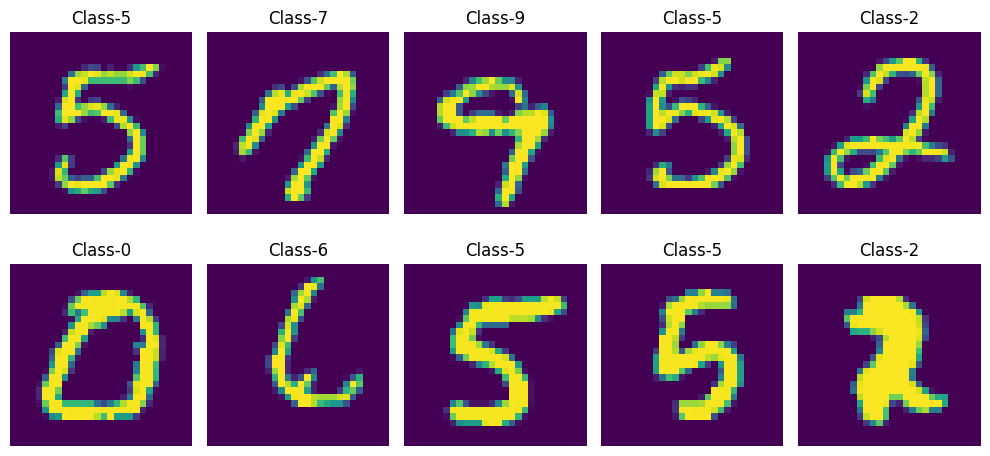

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28,28), cmap='viridis')
    ax.set_title(f'Class-{y_train.iloc[i]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test  = keras.utils.to_categorical(y_test, num_classes)

In [ ]:
model = Sequential()

model.add(Conv2D(
    32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=input_shape
))

model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(
    64,
    kernel_size=(3,3),
    activation='relu'
))

model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(
    units=10,
    activation='softmax'
))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_fit = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.2
)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8312 - loss: 0.6567 - val_accuracy: 0.9312 - val_loss: 0.2173
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9502 - loss: 0.1634 - val_accuracy: 0.9582 - val_loss: 0.1384
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9669 - loss: 0.1077 - val_accuracy: 0.9663 - val_loss: 0.1028
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9748 - loss: 0.0825 - val_accuracy: 0.9693 - val_loss: 0.0887
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9789 - loss: 0.0683 - val_accuracy: 0.9775 - val_loss: 0.0740
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9816 - loss: 0.0568 - val_accuracy: 0.9768 - val_loss: 0.0713
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9854 - loss: 0.0470 - val_accuracy: 0.9780 - val_loss: 0.0701
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9879 - loss: 0.0407 - val_accuracy: 0

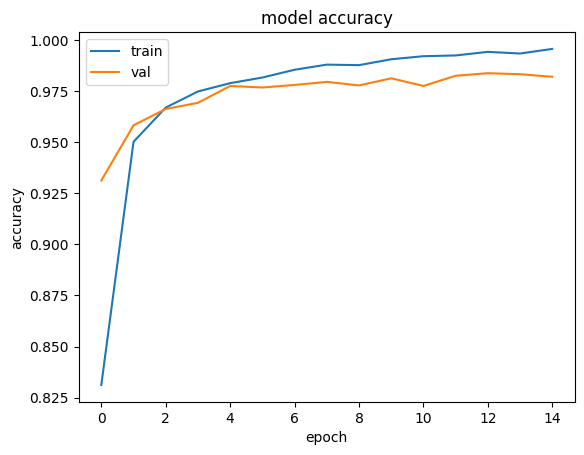

In [ ]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

plt.legend(['train', 'val'], loc='upper left')

plt.show()

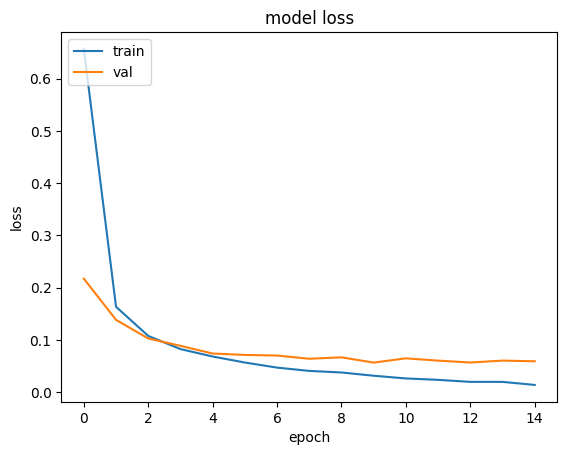

In [ ]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')

plt.legend(['train', 'val'], loc='upper left')

plt.show()

In [ ]:
score = model.evaluate(
    X_test,
    y_test,
    verbose=2
)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 1s - 4ms/step - accuracy: 0.9830 - loss: 0.0570
Test loss: 0.05699353665113449
Test accuracy: 0.9829983115196228


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step
[[8.7990820e-06 7.4504870e-03 9.9253619e-01 3.1195060e-11 2.0745150e-18
  2.2840277e-13 4.4912995e-06 1.8631274e-17 8.8710700e-10 1.5017937e-19]]
2 2


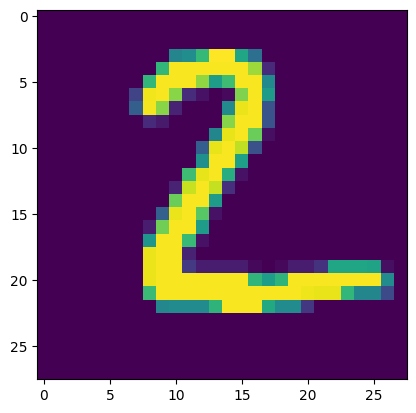

In [ ]:
predict = model.predict(X_test[:1])

print(predict)
print(np.argmax(predict),
      np.argmax(y_test[0]))

plt.imshow(
    X_test[:1].reshape(28,28)
)

plt.show()

In [ ]:
model.save_weights('cnn.weights.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
[[2.6805372e-07 9.9994731e-01 1.1149468e-05 1.7280247e-07 1.7173528e-05
  8.2113935e-08 6.5821964e-06 1.0561824e-05 6.6343273e-06 1.9806826e-08]]
1 1


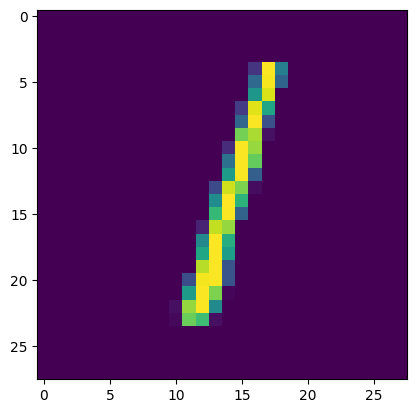

In [ ]:
model = Sequential()

model.add(Conv2D(
    32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=input_shape
))

model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(
    64,
    kernel_size=(3,3),
    activation='relu'
))

model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(
    units=10,
    activation='softmax'
))

model.load_weights('cnn.weights.h5')

predict = model.predict(X_test[1:2])

print(predict)
print(np.argmax(predict),
      np.argmax(y_test[1]))

plt.imshow(
    X_test[1:2].reshape(28,28)
)

plt.show()